In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("myntra_dataset.csv")

In [24]:
data.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52120 entries, 0 to 52119
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand_name         52120 non-null  object 
 1   pants_description  52120 non-null  object 
 2   price              52120 non-null  float64
 3   MRP                52120 non-null  float64
 4   discount_percent   52120 non-null  float64
 5   ratings            52120 non-null  float64
 6   number_of_ratings  52120 non-null  float64
dtypes: float64(5), object(2)
memory usage: 2.8+ MB


In [5]:
data.describe()

,price,MRP,discount_percent,ratings,number_of_ratings
count,52120.000000,52120.000000,52120.000000,52120.000000,52120.000000
mean,1594.515445,3180.398438,1.648256,3.997794,91.568937
std,1495.972325,2201.883218,4.687529,0.420404,433.918513
min,337.000000,499.000000,0.020000,1.000000,5.000000
25%,989.000000,2499.000000,0.400000,3.800000,16.000000
50%,1439.000000,2999.000000,0.500000,4.000000,35.000000
75%,1829.000000,3499.000000,0.630000,4.200000,74.000000
max,54000.000000,72000.000000,64.000000,5.000000,30700.000000


In [6]:
data.isnull().sum()

brand_name           0
pants_description    0
price                0
MRP                  0
discount_percent     0
ratings              0
number_of_ratings    0
dtype: int64

In [7]:
data['brand_name'].nunique()

417

In [8]:
data['pants_description'].nunique()

2680

In [9]:
data.duplicated().sum()

np.int64(17047)

## Data visuallsation

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt 

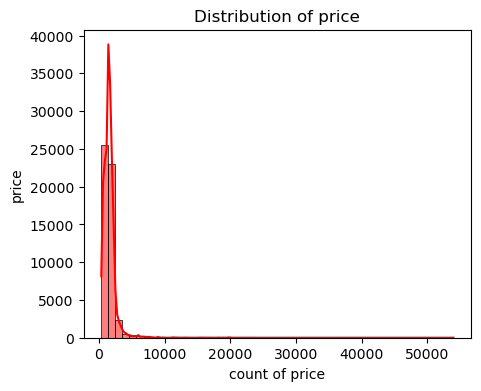

In [11]:
plt.figure(figsize=(5,4))
sns.histplot(data["price"],bins=50,kde=True,color='Red')
plt.title("Distribution of price")
plt.ylabel("price")
plt.xlabel("count of price")
plt.show()

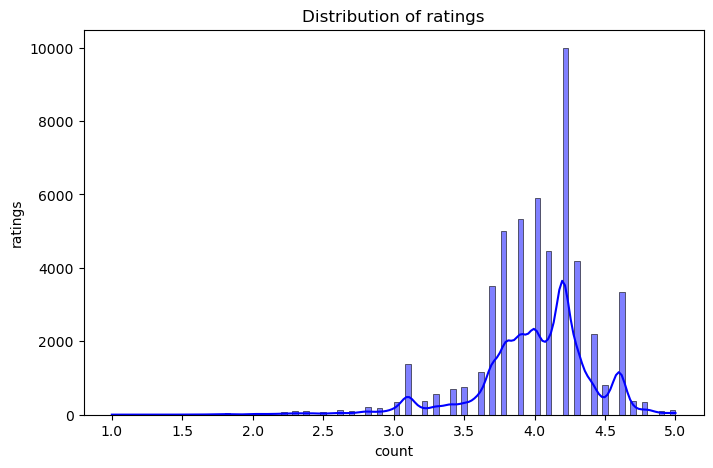

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data['ratings'],bins=100,kde=True ,color='blue')
plt.title("Distribution of ratings")
plt.ylabel("ratings")
plt.xlabel("count")
plt.show()

In [13]:
corr=data.corr(numeric_only=True)

In [14]:
corr

,price,MRP,discount_percent,ratings,number_of_ratings
price,1.000000,0.938008,-0.099100,0.084213,-0.034312
MRP,0.938008,1.000000,-0.008608,0.052942,-0.040991
discount_percent,-0.099100,-0.008608,1.000000,-0.018007,-0.002241
ratings,0.084213,0.052942,-0.018007,1.000000,-0.009406
number_of_ratings,-0.034312,-0.040991,-0.002241,-0.009406,1.000000


<Axes: >

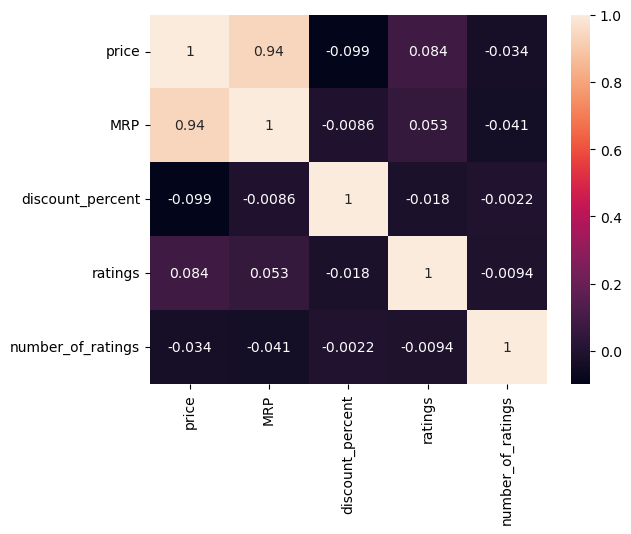

In [15]:
sns.heatmap(corr,annot=True)

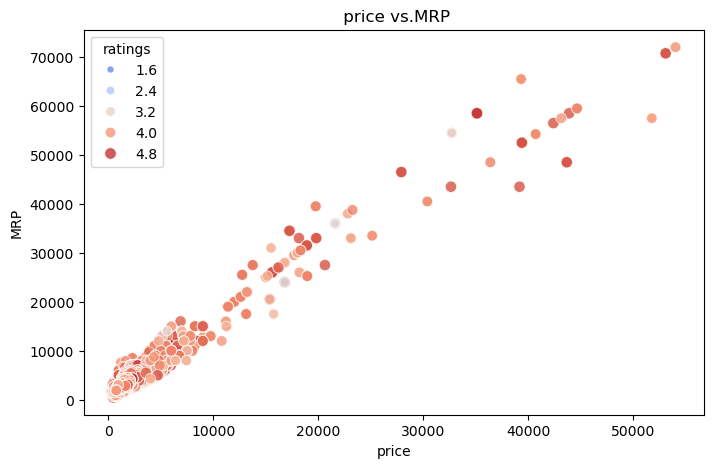

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data,x='price',y= 'MRP',hue= 'ratings',size='ratings',palette='coolwarm',alpha=0.8)
plt.title(" price vs.MRP")
plt.show()

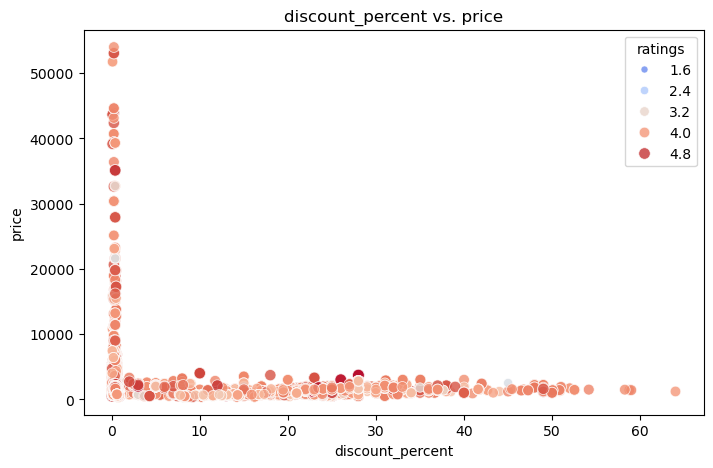

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data,x='discount_percent',y= 'price',hue= 'ratings',size='ratings',palette='coolwarm',alpha=0.8)
plt.title("discount_percent vs. price")
plt.show()

In [27]:
top_sales = data.groupby("brand_name")["price"].sum().sort_values(ascending=False).head(10)

In [29]:
top_sales

brand_name
Flying Machine               9423026.0
WROGN                        7480803.0
United Colors of Benetton    7304882.0
Levis                        4190911.0
Mufti                        3562587.0
Roadster                     2747401.0
FUGAZEE                      2132761.0
SPYKAR                       2048071.0
Calvin Klein Jeans           1816166.0
U.S. Polo Assn. Denim Co.    1726390.0
Name: price, dtype: float64

C:\Users\DELL\AppData\Local\Temp\ipykernel_16012\3706292867.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sales.values  ,y=top_sales.index, palette = 'mako')


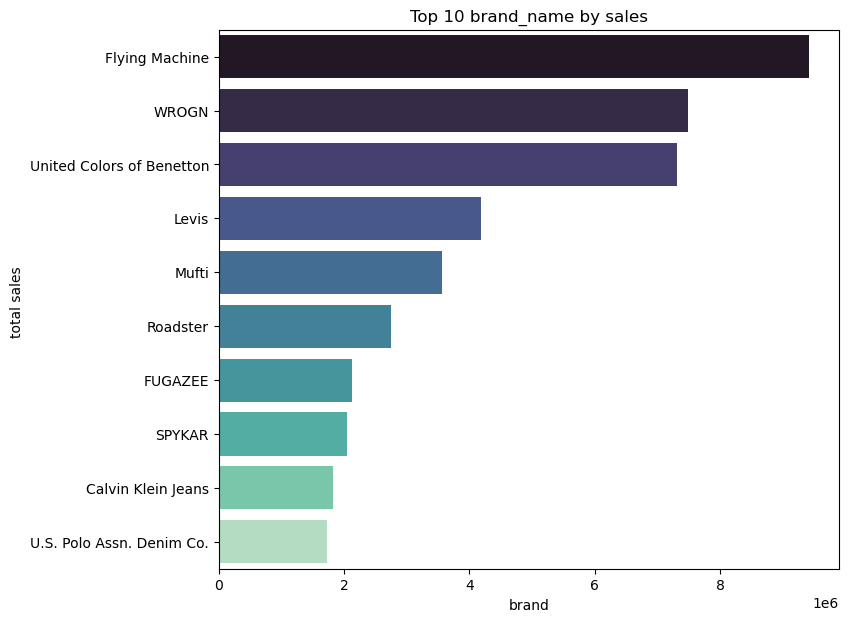

In [30]:
plt.figure(figsize=(8,7))
sns.barplot(x=top_sales.values  ,y=top_sales.index, palette = 'mako')
plt.title("Top 10 brand_name by sales")
plt.ylabel("total sales ")
plt.xlabel("brand")
plt.show()

In [34]:
top_ratings = data.groupby("pants_description")["number_of_ratings"].sum().sort_values(ascending=False).head(10)

In [35]:
top_ratings

pants_description
Men Slim Fit Jeans                930769.0
Men Skinny Fit Jeans              341140.0
Men Relaxed Fit Jeans             336729.0
Men Slim Fit Mid-Rise Jeans       260271.0
Men 511 Slim Fit Jeans            206814.0
Men Slim Fit Stretchable Jeans    179677.0
Men Tapered Fit Jeans             168727.0
Men Mid-Rise Regular Fit Jeans    150549.0
Men Straight Fit Jeans            124973.0
Men Regular Fit Mid-Rise Jeans    124046.0
Name: number_of_ratings, dtype: float64

C:\Users\DELL\AppData\Local\Temp\ipykernel_16012\70887576.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ratings.values  ,y=top_ratings.index, palette = 'mako')


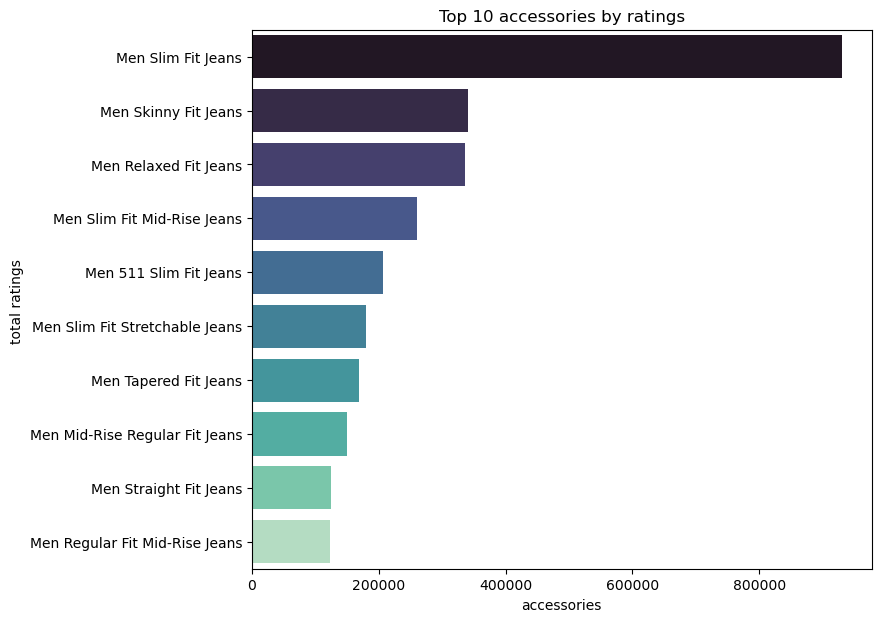

In [37]:
plt.figure(figsize=(8,7))
sns.barplot(x=top_ratings.values  ,y=top_ratings.index, palette = 'mako')
plt.title("Top 10 accessories by ratings")
plt.ylabel("total ratings ")
plt.xlabel("accessories")
plt.show()